In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("train.csv")
df.shape

(404290, 6)

In [3]:
df.sample(10)

,id,qid1,qid2,question1,question2,is_duplicate
266703,266703,383921,383922,How do I remove a massive amount of air from i...,Is the Epson L210 worth it to buy? Are Ink Tan...,0
309305,309305,433275,433276,What are the best and worst things about publi...,What are the best and worst things about publi...,0
168101,168101,96216,260463,What's the worst hotel in Málaga?,What's the worst hotel in Australia?,0
138555,138555,77372,220591,Why is life so unfair?,"Why do we say ""life is beautiful"" when it is u...",0
77721,77721,132654,132655,Every time I start my PC startup repair starts...,"Can I register for JEE Mains, if on the Aadhar...",0
122644,122644,198465,198466,"As a college student, how can I earn money by ...",How can I earn money as a college student?,1
109012,109012,178985,178986,What is difference between cryonics and cryoge...,What's the difference between cryonics and cry...,1
218567,218567,265428,239658,How do atheists explain demonic possession?,How can one explain the phenomenon of demonic ...,0
151524,151524,238238,238239,"What's the easiest STD to contract? Also, can ...",Can I sue someone for giving me spoilers?,0
93229,93229,53181,155924,Who do you think is the best politician in his...,Who are the best politicians of Indian history?,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [5]:
# missing values
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [6]:
# duplicate rows
df.duplicated().sum()

np.int64(0)

is_duplicate
0    255027
1    149263
Name: count, dtype: int64
is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

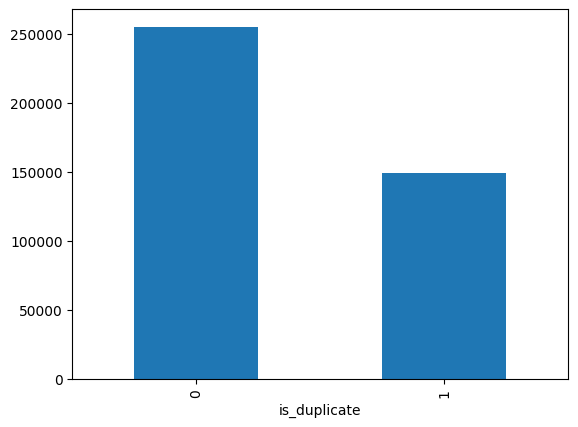

In [7]:
# Distribution of duplicate and non-duplicate questions

print(df['is_duplicate'].value_counts())
print((df['is_duplicate'].value_counts()/df['is_duplicate'].count())*100)
df['is_duplicate'].value_counts().plot(kind='bar')

In [8]:
# Repeated questions

qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print('Number of unique questions',np.unique(qid).shape[0])
x = qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number of unique questions 537933
Number of questions getting repeated 111780


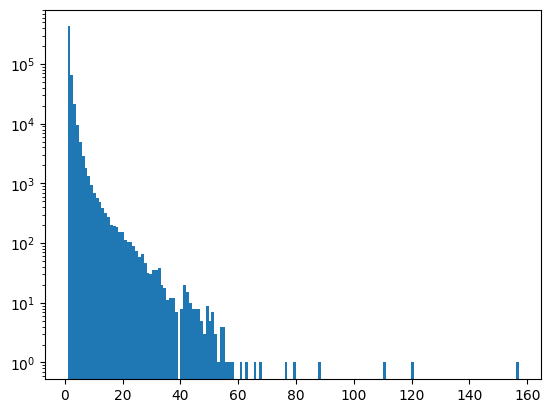

In [9]:
# Repeated questions histogram

plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()